# Car Price Prediction Model

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error

In [17]:
df=pd.read_csv("car data.csv")
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [18]:
print(df.shape)

(301, 9)


In [19]:
print(df.info)

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  
1

In [20]:
print(df.describe())

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [21]:
df.drop(['Car_Name'],axis=1,inplace=True)

In [22]:
print(df.head())

   Year  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0  2014           3.35           5.59       27000    Petrol       Dealer   
1  2013           4.75           9.54       43000    Diesel       Dealer   
2  2017           7.25           9.85        6900    Petrol       Dealer   
3  2011           2.85           4.15        5200    Petrol       Dealer   
4  2014           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  
0       Manual      0  
1       Manual      0  
2       Manual      0  
3       Manual      0  
4       Manual      0  


In [23]:
df['Car_Age']=2026-df['Year']
df.drop(['Year'],axis=1,inplace=True)

In [24]:
print(df.head())

   Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0           3.35           5.59       27000    Petrol       Dealer   
1           4.75           9.54       43000    Diesel       Dealer   
2           7.25           9.85        6900    Petrol       Dealer   
3           2.85           4.15        5200    Petrol       Dealer   
4           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       12  
1       Manual      0       13  
2       Manual      0        9  
3       Manual      0       15  
4       Manual      0       12  


In [25]:
df = pd.get_dummies(df, drop_first=True)

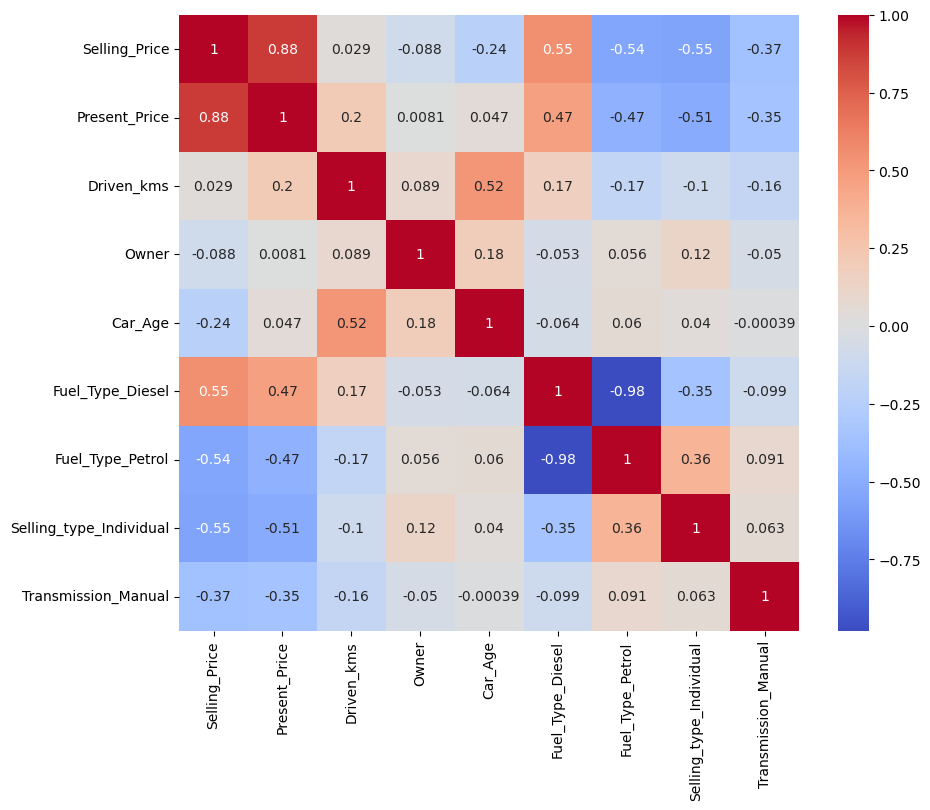

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [27]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
y_pred = model.predict(X_test)

In [34]:
print(y_pred)

[ 0.4438 10.9098  4.9315  0.2159  7.7988  6.2535  1.1065  0.5876  0.469
  6.896   7.983   1.1031  8.3646  0.453   5.273   2.5255  1.1645 14.2574
  0.4671  1.5505  0.3279  8.0661  4.743   2.7455  0.5016  3.5115  5.404
  3.1475  1.1817  1.1751  0.4141 10.1675  0.4586  2.5775  7.8795  4.1135
  6.4288  6.3353  2.4715  7.0425  4.0111  3.5444  4.89    0.5688  6.1155
  0.733   8.394   7.0795  2.9005  3.619   4.999   1.4985 22.6388 20.7138
  6.4225 10.8159  5.155   9.2844  2.6944  6.7145  0.2318]


In [31]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9594566919773236
MAE: 0.6368655737704919


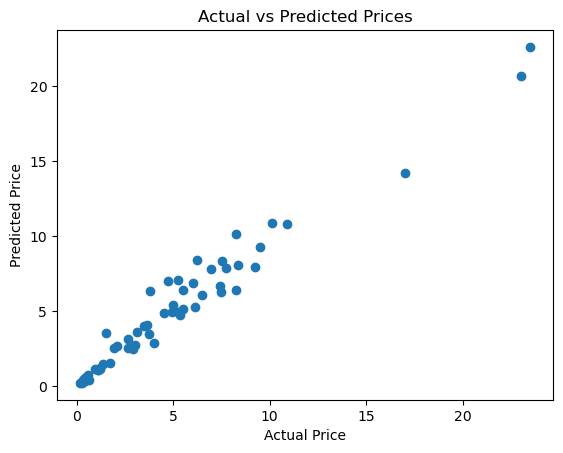

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

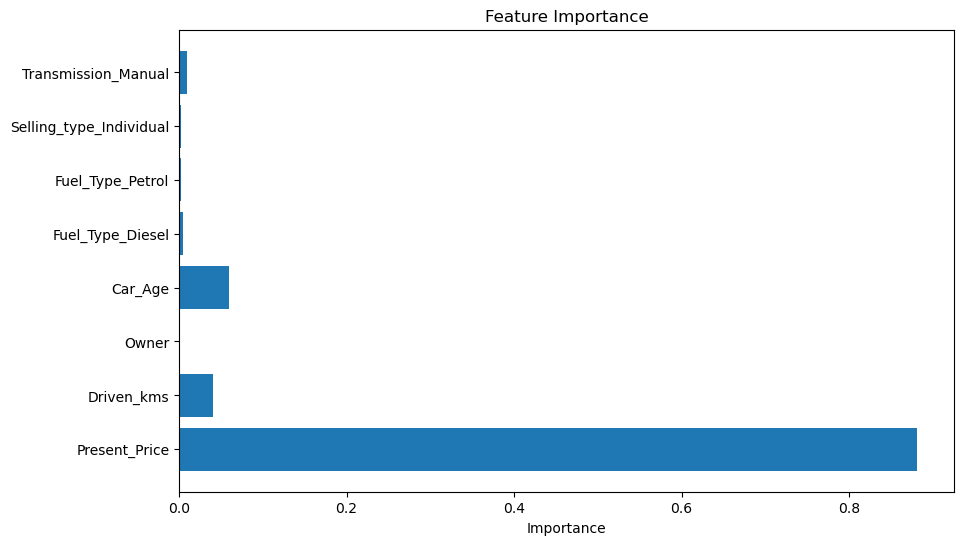

In [33]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()